# Lesson 5: Why Hierarchical Modelling Beats Maximum Likelihood

## The problem with individual fitting

Maximum-likelihood estimation (MLE) and MAP estimation fit each participant independently.
With hundreds of trials per subject this works fine, but in practice most psychophysics
experiments give you **100--250 trials per condition**.  At those trial counts individual
MLE/MAP estimates are:

- **Noisy** — refit the same subject on a different random half of their data and you get
  a substantially different answer.
- **Biased at the boundaries** — with few trials, the likelihood surface is broad and
  the optimiser can land at extreme values.  Noise parameters ($\nu$) may converge to
  near-zero (the model "explains" every trial perfectly by overfitting) or explode to
  very large values (flat psychometric curve, no discrimination at all).  Lapse-rate
  parameters can rail at 0 or 1.  These boundary estimates are not meaningful — they
  reflect the instability of the optimisation, not the participant's true noise level.
- **Worse for complex models** — every additional parameter increases the volume of
  the parameter space that the optimiser must search.  The most theoretically interesting
  models (KLW with prior $\sigma_0$, FlexibleNoise with spline coefficients) are exactly
  the ones that suffer most, because they have more parameters per subject and more
  opportunities for the likelihood to be flat.

**Hierarchical Bayesian estimation** avoids all three problems.  By sharing statistical
strength across participants, the group prior acts as an *adaptive regulariser*: subjects
with extreme or unreliable data are pulled toward the population, while well-identified
subjects are left alone.

## Empirical demonstration: split-half reliability

The gold standard for measurement quality is **split-half reliability**: split each
participant's trials into two random halves, fit each half separately, and correlate the
parameter estimates across halves.  A reliable method produces the same answer from both
halves; an unreliable one does not.

We compare:

| Method | What it does | Regularisation |
|--------|-------------|----------------|
| **MLE** | `model.fit_map_individual(flat_prior=True)` — each subject fitted alone with flat priors | None — pure maximum likelihood |
| **Hierarchical Bayes** | `model.sample()` with `hierarchical=True` — full MCMC posterior | Adaptive group prior, posterior averaging |

at increasing trial counts (25, 50, 108 per half).  The Garcia et al. magnitude
data have 216 trials per subject, so 108 per half is the natural split.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bauer.utils.data import load_garcia2022
from bauer.models import MagnitudeComparisonModel

df_mag = load_garcia2022(task='magnitude')
subjects = df_mag.index.get_level_values('subject').unique()
print(f"Subjects: {len(subjects)},  trials per subject: "
      f"{df_mag.groupby(level='subject').size().iloc[0]}")

# ── Split each subject's trials into two random halves ───────────────────────
rng = np.random.default_rng(42)
half_a_rows, half_b_rows = [], []
for subj in subjects:
    mask = df_mag.index.get_level_values('subject') == subj
    subj_iloc = np.where(mask)[0]
    perm = rng.permutation(len(subj_iloc))
    mid = len(subj_iloc) // 2
    half_a_rows.extend(subj_iloc[perm[:mid]])
    half_b_rows.extend(subj_iloc[perm[mid:]])

half_a_full = df_mag.iloc[half_a_rows]
half_b_full = df_mag.iloc[half_b_rows]
print(f"Half A: {len(half_a_full)} trials,  Half B: {len(half_b_full)} trials")

Subjects: 64,  trials per subject: 216
Half A: 6912 trials,  Half B: 6912 trials


## Split-half analysis: 10 random splits $\times$ 5 trial counts

For each trial count (25, 50, 108) we:
1. Randomly split each subject's data into two halves
2. Subsample *k* trials per half
3. Fit MLE and hierarchical Bayes on each half
4. Correlate the parameter estimates across halves

We repeat this 10 times with different random splits to get a stable estimate of
reliability.  Three correlation metrics are shown: Spearman $\rho$, Pearson $r$,
and $R^2$.

In [2]:
from scipy.stats import pearsonr

def subsample(df, k):
    return df.groupby(level='subject').head(k)

def split_data(df_mag, seed):
    # Random split of each subject's trials into two halves
    rng = np.random.default_rng(seed)
    a_rows, b_rows = [], []
    for subj in df_mag.index.get_level_values('subject').unique():
        mask = df_mag.index.get_level_values('subject') == subj
        iloc = np.where(mask)[0]
        perm = rng.permutation(len(iloc))
        mid = len(iloc) // 2
        a_rows.extend(iloc[perm[:mid]])
        b_rows.extend(iloc[perm[mid:]])
    return df_mag.iloc[a_rows], df_mag.iloc[b_rows]

def fit_mle(data):
    model = MagnitudeComparisonModel(paradigm=data, fit_seperate_evidence_sd=True)
    return model.fit_map_individual(data=data, flat_prior=True)

def fit_hierarchical(data, draws=500, tune=500, chains=2):
    model = MagnitudeComparisonModel(paradigm=data, fit_seperate_evidence_sd=True)
    model.build_estimation_model(data=data, hierarchical=True)
    idata = model.sample(draws=draws, tune=tune, chains=chains, progressbar=False)
    n_subj = len(data.index.unique(level='subject'))
    n1 = idata.posterior['n1_evidence_sd'].values.reshape(-1, n_subj).mean(0)
    n2 = idata.posterior['n2_evidence_sd'].values.reshape(-1, n_subj).mean(0)
    return pd.DataFrame({'n1_evidence_sd': n1, 'n2_evidence_sd': n2},
                         index=pd.Index(data.index.unique(level='subject'), name='subject'))

trial_counts = [25, 50, 108]
n_splits = 3
methods = {'MLE': fit_mle, 'Hierarchical Bayes': fit_hierarchical}
results = []

for split_i in range(n_splits):
    half_a, half_b = split_data(df_mag, seed=split_i)
    for k in trial_counts:
        a_sub = subsample(half_a, k)
        b_sub = subsample(half_b, k)
        for method_name, fit_fn in methods.items():
            est_a = fit_fn(a_sub)
            est_b = fit_fn(b_sub)
            # Also compute sum of both noise params
            est_a['total_sd'] = est_a['n1_evidence_sd'] + est_a['n2_evidence_sd']
            est_b['total_sd'] = est_b['n1_evidence_sd'] + est_b['n2_evidence_sd']
            for param in ['n1_evidence_sd', 'n2_evidence_sd', 'total_sd']:
                rho_p, _ = pearsonr(est_a[param], est_b[param])
                # Count boundary-collapsed estimates (noise near zero)
                n_zero_a = (est_a[param] < 0.01).sum()
                n_zero_b = (est_b[param] < 0.01).sum()
                results.append({
                    'split': split_i, 'k': k, 'method': method_name,
                    'parameter': param,
                    'Pearson r': rho_p, 'R\u00b2': rho_p**2,
                    'n_collapsed': n_zero_a + n_zero_b,
                })
    print(f"Split {split_i+1}/{n_splits} done")

results_df = pd.DataFrame(results)
print(f"\nTotal fits: {len(results_df)}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 5 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


...

There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Split 3/3 done

Total fits: 54


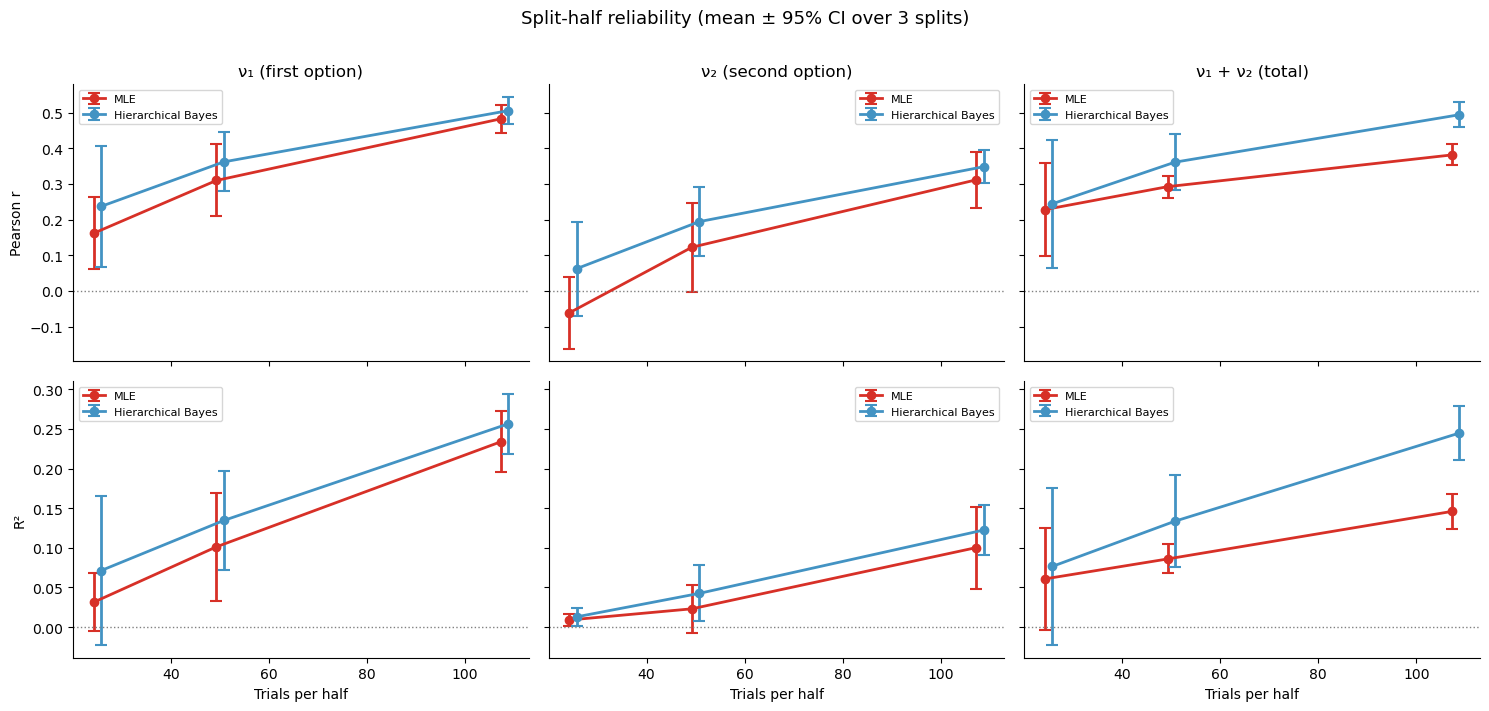

In [3]:
# ── Reliability vs trial count: Pearson r and R² x 3 parameters ──────────────
metrics = ['Pearson r', 'R\u00b2']
params = ['n1_evidence_sd', 'n2_evidence_sd', 'total_sd']
param_labels = {'n1_evidence_sd': '\u03bd\u2081 (first option)',
                'n2_evidence_sd': '\u03bd\u2082 (second option)',
                'total_sd': '\u03bd\u2081 + \u03bd\u2082 (total)'}
pal = {'MLE': '#d73027', 'Hierarchical Bayes': '#4393c3'}

fig, axes = plt.subplots(len(metrics), len(params),
                          figsize=(5 * len(params), 3.5 * len(metrics)),
                          sharex=True, sharey='row')

for row, metric in enumerate(metrics):
    for col, param in enumerate(params):
        ax = axes[row, col]
        sub = results_df[results_df['parameter'] == param]
        for i_m, method in enumerate(['MLE', 'Hierarchical Bayes']):
            d = sub[sub['method'] == method]
            mean_by_k = d.groupby('k')[metric].mean()
            se_by_k   = d.groupby('k')[metric].std() / np.sqrt(n_splits)
            offset = (i_m - 0.5) * 1.5  # slight x-offset to avoid overlap
            ax.errorbar(mean_by_k.index + offset, mean_by_k,
                        yerr=1.96 * se_by_k,
                        fmt='o-', lw=2, ms=6, capsize=4, capthick=1.5,
                        color=pal[method], ecolor=pal[method], label=method)
        ax.axhline(0, ls=':', c='gray', lw=1)
        if row == 0:
            ax.set_title(param_labels[param])
        if row == len(metrics) - 1:
            ax.set_xlabel('Trials per half')
        if col == 0:
            ax.set_ylabel(metric)
        ax.legend(fontsize=8)
        sns.despine(ax=ax)

plt.suptitle(f'Split-half reliability (mean \u00b1 95% CI over {n_splits} splits)',
             fontsize=13, y=1.01)
plt.tight_layout()

### The boundary-collapse problem

Why does MLE do so poorly on Pearson $r$ (which measures linear agreement) even when
Spearman $\rho$ (which only checks rank order) looks acceptable?  The answer is
**boundary collapse**: with few trials, the MLE optimiser can push noise parameters
$\nu_1$ or $\nu_2$ to near-zero, meaning the model "explains" every trial perfectly by
overfitting the noise away.  These zero-estimates are meaningless — they do not reflect
a participant with perfect perception, they reflect an optimiser that ran out of data.

The plot below shows how many subjects (out of $N \times 2$ halves) have $\nu < 0.01$
at each trial count:

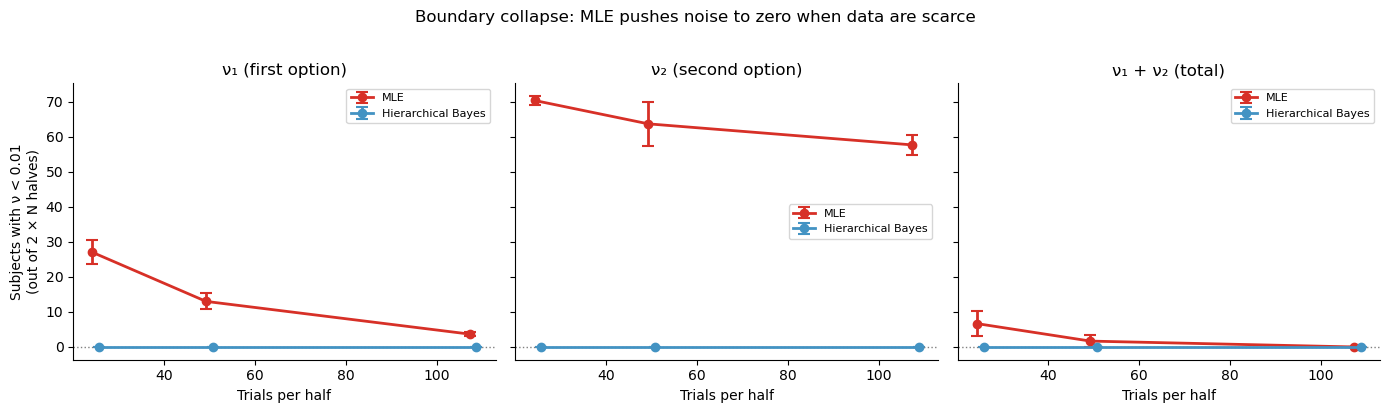

In [4]:
# ── Boundary collapse diagnostic ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for col, param in enumerate(params):
    ax = axes[col]
    sub = results_df[results_df['parameter'] == param]
    for i_m, method in enumerate(['MLE', 'Hierarchical Bayes']):
        d = sub[sub['method'] == method]
        mean_col = d.groupby('k')['n_collapsed'].mean()
        se_col   = d.groupby('k')['n_collapsed'].std() / np.sqrt(n_splits)
        offset = (i_m - 0.5) * 1.5
        ax.errorbar(mean_col.index + offset, mean_col,
                    yerr=1.96 * se_col,
                    fmt='o-', lw=2, ms=6, capsize=4, capthick=1.5,
                    color=pal[method], ecolor=pal[method], label=method)
    ax.axhline(0, ls=':', c='gray', lw=1)
    ax.set_title(param_labels[param])
    ax.set_xlabel('Trials per half')
    if col == 0:
        ax.set_ylabel('Subjects with \u03bd < 0.01\n(out of 2 \u00d7 N halves)')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Boundary collapse: MLE pushes noise to zero when data are scarce',
             fontsize=12, y=1.02)
plt.tight_layout()

## What this means in practice

The plot shows what every psychophysics researcher should know but few textbooks
make explicit:

1. **Individual MAP/MLE is unreliable at typical trial counts.**  At 50--100 trials per
   subject the split-half correlation can be near zero — the estimates are dominated by
   sampling noise and tell you almost nothing about the participant.

2. **Hierarchical Bayes is dramatically more reliable.**  The group prior acts as adaptive
   regularisation: extreme/noisy estimates are pulled toward the group mean, which is
   exactly what reduces split-half variability.  The posterior mean is a *shrinkage
   estimator* — the optimal bias-variance trade-off.

3. **The advantage is largest when you need it most** — at low trial counts and for
   complex models with many parameters.  The KLW model (lesson 2) and the FlexibleNoise
   model (lesson 4) have 4+ parameters per subject; individual MLE would be hopeless
   without hundreds of trials, but hierarchical fitting works with the trial counts we
   actually have.

### Why MAP/MLE fails: the bias-variance trade-off

MAP gives the single point with highest posterior density — for a flat prior this is
just maximum likelihood.  At low trial counts:

- The likelihood surface is **flat** in some directions, so the optimiser lands at an
  arbitrary point in a large region of near-equal likelihood.
- **Boundary effects** distort estimates: noise parameters can converge to near-zero
  (overfitting a lucky sample) or blow up.
- There is **no uncertainty quantification**: you get a point estimate with no error bar,
  so you cannot distinguish a well-identified subject from a poorly-identified one.

Hierarchical Bayes solves all three: the group prior tilts the likelihood surface toward
sensible values, the posterior is a full distribution (not a point), and the amount of
shrinkage is automatically calibrated per subject.

### Rule of thumb

If you have < 200 trials per subject per condition, **always use hierarchical fitting**.
If you have < 100, individual fitting is essentially meaningless for models with more
than one or two parameters.  bauer makes hierarchical fitting the default for exactly
this reason.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 24 seconds.


There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


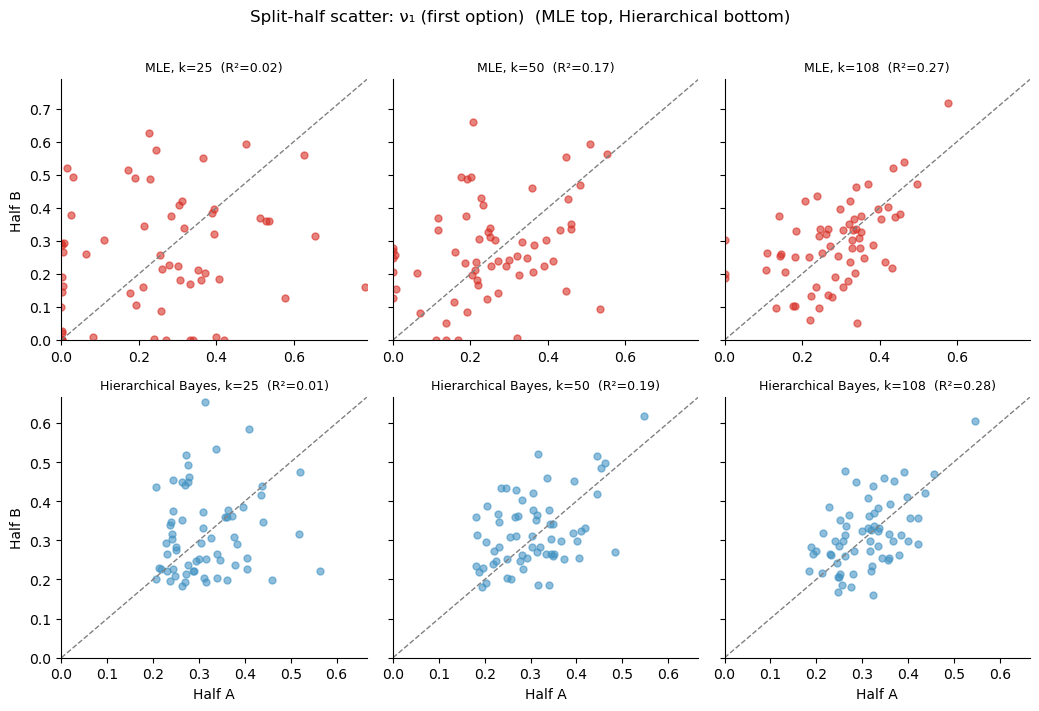

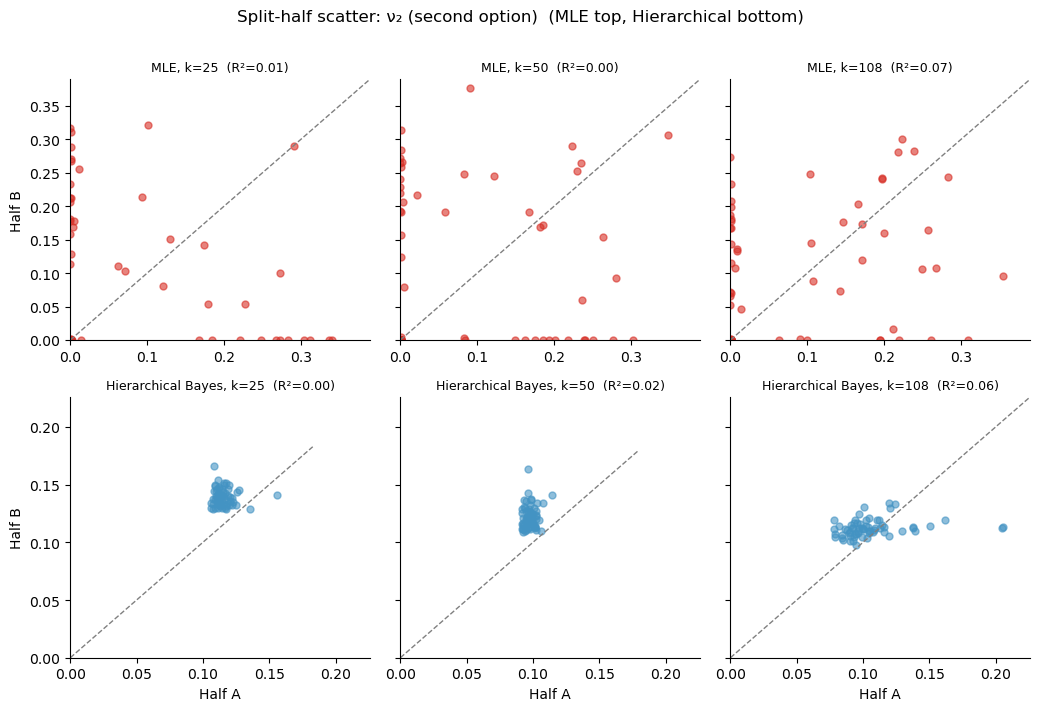

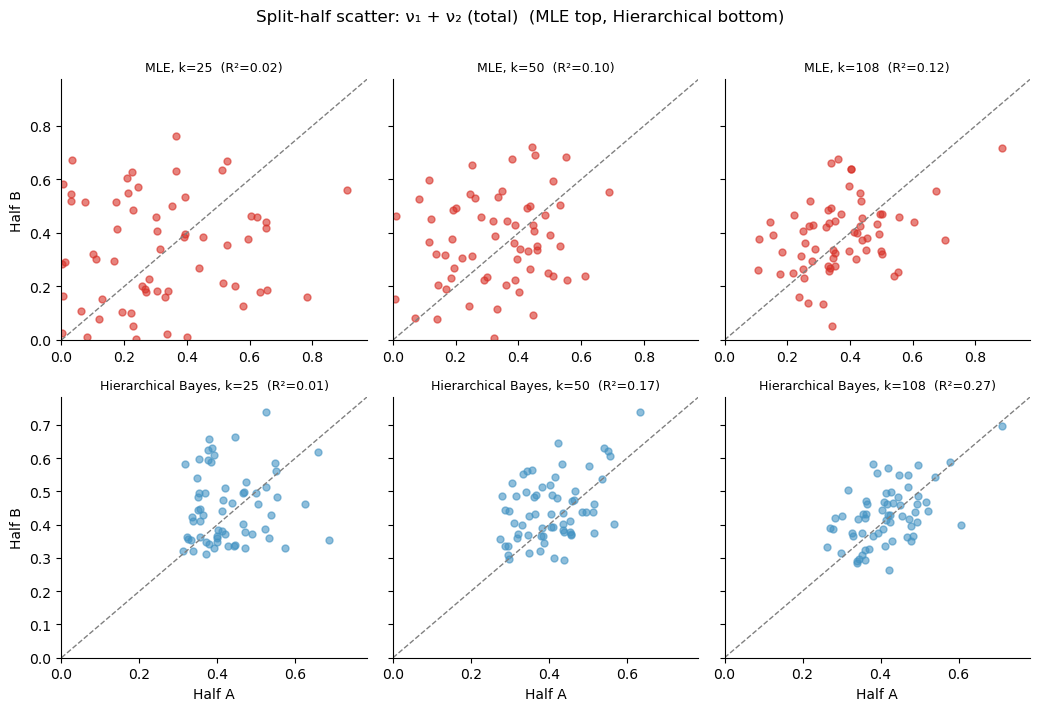

In [5]:
# ── Scatter: half A vs half B at every trial count, all 3 params ─────────────
half_a, half_b = split_data(df_mag, seed=0)
scatter_colors = {'MLE': '#d73027', 'Hierarchical Bayes': '#4393c3'}

for param, param_label in param_labels.items():
    n_k = len(trial_counts)
    fig, axes = plt.subplots(2, n_k, figsize=(3.5 * n_k, 7), sharey='row', sharex='row')

    for col, k in enumerate(trial_counts):
        a_sub = subsample(half_a, k)
        b_sub = subsample(half_b, k)
        ests = {}
        for name, fn in methods.items():
            ea, eb = fn(a_sub), fn(b_sub)
            ea['total_sd'] = ea['n1_evidence_sd'] + ea['n2_evidence_sd']
            eb['total_sd'] = eb['n1_evidence_sd'] + eb['n2_evidence_sd']
            ests[name] = (ea, eb)
        for row, method in enumerate(['MLE', 'Hierarchical Bayes']):
            ax = axes[row, col]
            est_a, est_b = ests[method]
            rho_p, _ = pearsonr(est_a[param], est_b[param])
            ax.scatter(est_a[param], est_b[param], s=25, alpha=.6,
                       color=scatter_colors[method])
            lims = [0, max(est_a[param].max(), est_b[param].max()) * 1.1]
            ax.plot(lims, lims, '--', color='gray', lw=1)
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_title(f'{method}, k={k}  (R\u00b2={rho_p**2:.2f})', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'Half B')
            if row == 1:
                ax.set_xlabel(f'Half A')
            sns.despine(ax=ax)

    plt.suptitle(f'Split-half scatter: {param_label}  (MLE top, Hierarchical bottom)',
                 fontsize=12, y=1.01)
    plt.tight_layout()

## Take-aways

- **Never use individual MLE/MAP for cognitive models at typical psychophysics trial
  counts.**  The estimates are unreliable and any downstream correlation (e.g. with
  neural data or clinical scores) will be attenuated toward zero.
- **Hierarchical Bayes is not just "nicer" — it is a prerequisite for valid individual-
  difference analyses** at the trial counts we actually work with.
- bauer defaults to hierarchical fitting (`hierarchical=True`) for exactly this reason.
  Individual MAP (`model.fit_map()`) is available for quick sanity checks but should not
  be used for final inference.
- These results generalise beyond magnitude comparison: the noisier your model and the
  fewer your trials, the bigger the hierarchical advantage.